# 07 Feature Engineering

This notebook prepares the Spotify dataset for the recommendation system.

The analysis focuses on:
- selecting useful recommendation features
- removing metadata and noise columns
- handling scaling differences
- preparing the final feature matrix
- understanding preprocessing decisions before modeling

## 1. Load Track and Audio Feature Data

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config.paths import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH)

In [2]:
tracks = con.execute("""
    SELECT *
    FROM tracks
""").df()

tracks.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(101939, 32)

In [3]:
tracks.head()

,column00,acousticness,album_id,analysis_url,artists_id,available_markets,country,danceability,disc_number,duration_ms,...,preview_url,speechiness,tempo,time_signature,track_href,track_name_prev,track_number,uri,valence,type
0,0,0.294,0D3QufeCudpQANOR7luqdr,https://api.spotify.com/v1/audio-analysis/5qlj...,['3mxJuHRn2ZWD5OofvJtDZY'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.698,1.0,235584.0,...,https://p.scdn.co/mp3-preview/1b05a902da3a251d...,0.0262,115.018,4.0,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,track_14,1.0,spotify:track:5qljLQuKnNJf4F4vfxQB0V,0.6220,track
1,1,0.863,1bcqsH5UyTBzmh9YizdsBE,https://api.spotify.com/v1/audio-analysis/3VAX...,['4xWMewm6CYMstu0sPgd9jJ'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,656960.0,...,https://p.scdn.co/mp3-preview/d8140736a6131cb5...,0.9220,115.075,3.0,https://api.spotify.com/v1/tracks/3VAX2MJdmdqA...,track_3,3.0,spotify:track:3VAX2MJdmdqARLSU5hPMpm,0.5890,track
2,2,0.750,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1L3Y...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.466,1.0,492840.0,...,https://p.scdn.co/mp3-preview/c8af28fb15185b18...,0.9440,79.565,4.0,https://api.spotify.com/v1/tracks/1L3YAhsEMrGV...,track_4,4.0,spotify:track:1L3YAhsEMrGVvCgDXj2TYn,0.0850,track
3,3,0.763,6FeJF5r8roonnKraJxr4oB,https://api.spotify.com/v1/audio-analysis/6aCe...,['2KQsUB9DRBcJk17JWX1eXD'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,316578.0,...,https://p.scdn.co/mp3-preview/7629b8e9f31f6e9b...,0.9380,112.822,3.0,https://api.spotify.com/v1/tracks/6aCe9zzoZmCo...,track_9,1.0,spotify:track:6aCe9zzoZmCojX7bbgKKtf,0.5330,track
4,4,0.770,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1Vo8...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.460,1.0,558880.0,...,https://p.scdn.co/mp3-preview/32be593c0eb82868...,0.9430,81.260,4.0,https://api.spotify.com/v1/tracks/1Vo802A38tPF...,track_2,2.0,spotify:track:1Vo802A38tPFHmje1h91um,0.0906,track


## 2. Selection of Audio Features

In [4]:
audio_feature_cols = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
    "duration_ms",
    "popularity"
]

In [5]:
feature_df = tracks[
    audio_feature_cols
].copy()

feature_df.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity
0,0.294,0.698,0.606,0.000003,0.151,-7.447,0.0262,115.018,0.6220,235584.0,28.0
1,0.863,0.719,0.308,0.000000,0.253,-10.340,0.9220,115.075,0.5890,656960.0,31.0
2,0.750,0.466,0.931,0.000000,0.938,-13.605,0.9440,79.565,0.0850,492840.0,31.0
3,0.763,0.719,0.126,0.000000,0.113,-20.254,0.9380,112.822,0.5330,316578.0,14.0
4,0.770,0.460,0.942,0.000000,0.917,-13.749,0.9430,81.260,0.0906,558880.0,32.0


## Feature Scales Without Duration

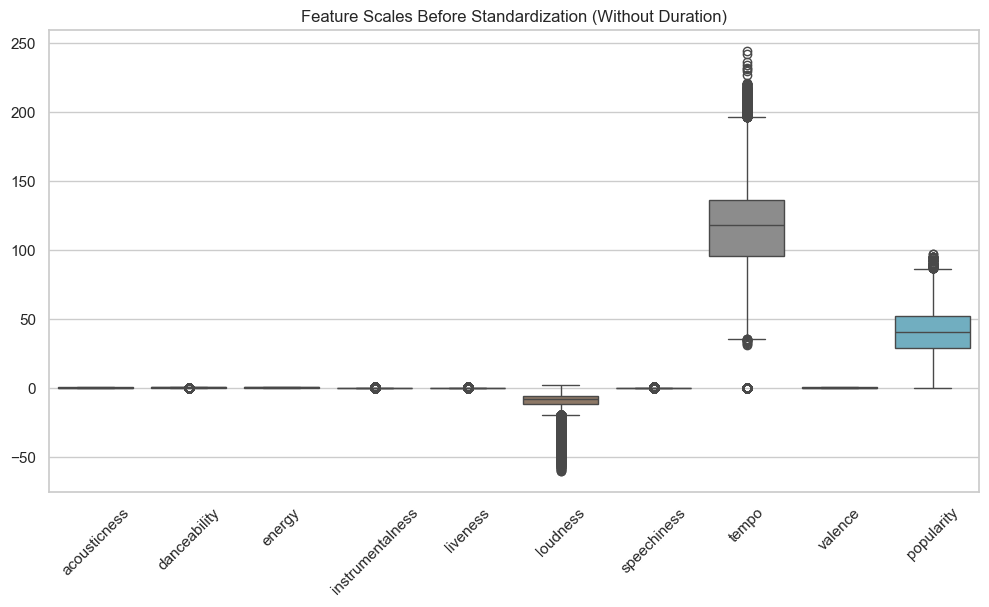

In [11]:
plot_cols = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
    "popularity"
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=feature_df[plot_cols]
)

plt.xticks(rotation=45)

plt.title("Feature Scales Before Standardization (Without Duration)")

plt.show()

Even after removing duration, features such as tempo and popularity still operate on much larger numerical ranges than most audio features. This confirms that scaling is necessary before using distance-based methods, otherwise variables with larger values could dominate the similarity calculation.

## 3. Feature Scale Comparison

In [6]:
feature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
acousticness,101939.0,0.352124,0.334855,0.0,0.0407,0.238000,0.6450,0.996
danceability,101939.0,0.586015,0.177724,0.0,0.4800,0.610000,0.7140,0.989
energy,101939.0,0.586479,0.260170,0.0,0.4110,0.629000,0.7980,1.000
instrumentalness,101939.0,0.148776,0.304024,0.0,0.0000,0.000037,0.0344,1.000
liveness,101939.0,0.197640,0.175391,0.0,0.0956,0.124000,0.2410,0.999
loudness,101939.0,-9.462720,6.198508,-60.0,-11.1490,-7.599000,-5.5090,2.719
speechiness,101939.0,0.128841,0.203324,0.0,0.0364,0.050600,0.1040,0.969
tempo,101939.0,118.358527,30.224074,0.0,95.9730,118.067000,136.0450,244.035
valence,101939.0,0.482813,0.261690,0.0,0.2710,0.477000,0.6930,0.993
duration_ms,101939.0,246770.803304,190430.295141,1155.0,184000.0000,216893.000000,261055.0000,5505831.000


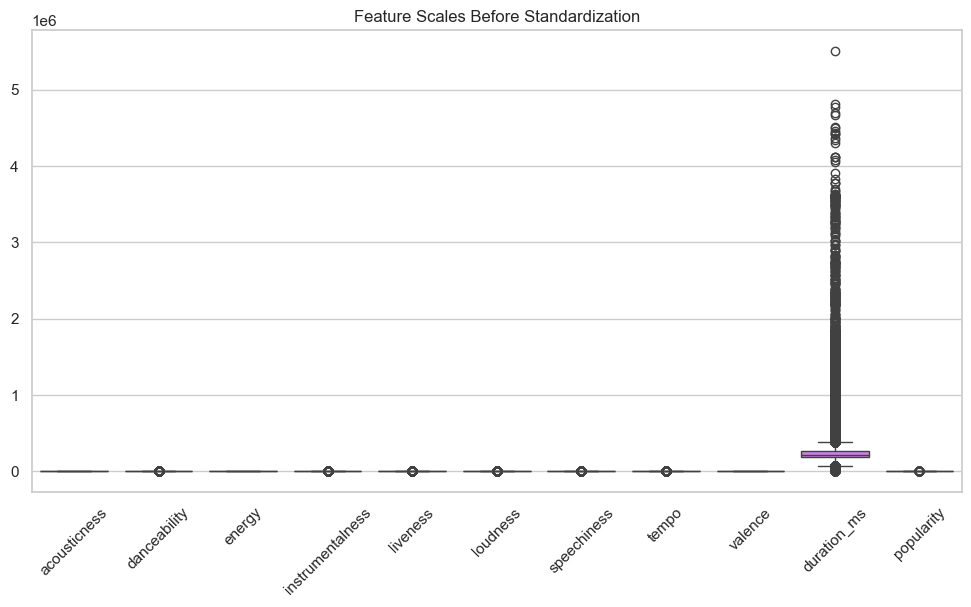

In [7]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=feature_df
)

plt.xticks(rotation=45)

plt.title("Feature Scales Before Standardization")

plt.show()

## 4. Standardization of Features

In [8]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    feature_df
)

In [9]:
scaled_df = pd.DataFrame(
    scaled_features,
    columns=audio_feature_cols
)

scaled_df.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity
0,-0.173579,0.630108,0.075031,-0.489350,-0.265923,0.325196,-0.504821,-0.110526,0.531880,-0.058745,-0.701717
1,1.525671,0.748269,-1.070377,-0.489359,0.315638,-0.141532,3.900983,-0.108640,0.405777,2.154023,-0.523047
2,1.188210,-0.675291,1.324219,-0.489359,4.221220,-0.668274,4.009186,-1.283537,-1.520172,1.292181,-0.523047
3,1.227033,0.748269,-1.769922,-0.489359,-0.482583,-1.740957,3.979676,-0.183184,0.191782,0.366578,-1.535513
4,1.247938,-0.709051,1.366499,-0.489359,4.101486,-0.691505,4.004267,-1.227456,-1.498773,1.638976,-0.463490


In [10]:
scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
acousticness,101939.0,-2.280674e-16,1.000005,-1.051575,-0.930029,-0.340816,0.874640,1.922860
danceability,101939.0,-4.572500e-16,1.000005,-3.297343,-0.596517,0.134957,0.720136,2.267484
energy,101939.0,-3.457256e-17,1.000005,-2.254223,-0.674481,0.163435,0.813013,1.589431
instrumentalness,101939.0,-7.249085e-18,1.000005,-0.489359,-0.489359,-0.489236,-0.376209,2.799876
liveness,101939.0,1.672866e-16,1.000005,-1.126862,-0.581791,-0.419866,0.247219,4.569016
loudness,101939.0,2.737924e-16,1.000005,-8.153176,-0.272047,0.300674,0.637853,1.965276
speechiness,101939.0,-1.106879e-16,1.000005,-0.633680,-0.454654,-0.384814,-0.122178,4.132143
tempo,101939.0,1.315988e-16,1.000005,-3.916054,-0.740656,-0.009646,0.585181,4.158178
valence,101939.0,7.388490e-18,1.000005,-1.844985,-0.809405,-0.022212,0.803195,1.949593
duration_ms,101939.0,-1.819241e-17,1.000005,-1.289800,-0.329628,-0.156897,0.075010,27.616856


StandardScaler was selected because the recommendation system will rely on distance-based similarity methods such as cosine similarity and K-Nearest Neighbors.

Standardization centers features around zero and scales them to unit variance, preventing features with larger numerical ranges from dominating similarity calculations.

In [13]:
comparison_df = pd.concat(
    [
        feature_df.head(1).T,
        scaled_df.head(1).T
    ],
    axis=1
)

comparison_df.columns = [
    "Original",
    "Scaled"
]

comparison_df

,Original,Scaled
acousticness,0.294000,-0.173579
danceability,0.698000,0.630108
energy,0.606000,0.075031
instrumentalness,0.000003,-0.489350
liveness,0.151000,-0.265923
loudness,-7.447000,0.325196
speechiness,0.026200,-0.504821
tempo,115.018000,-0.110526
valence,0.622000,0.531880
duration_ms,235584.000000,-0.058745


The comparison shows how the same track is transformed into standardized feature values. After scaling, values describe how far each feature is from the dataset average rather than representing the original measurement directly. This makes the features comparable for similarity-based recommendation models.

## 5. Comparison Before and After Scaling

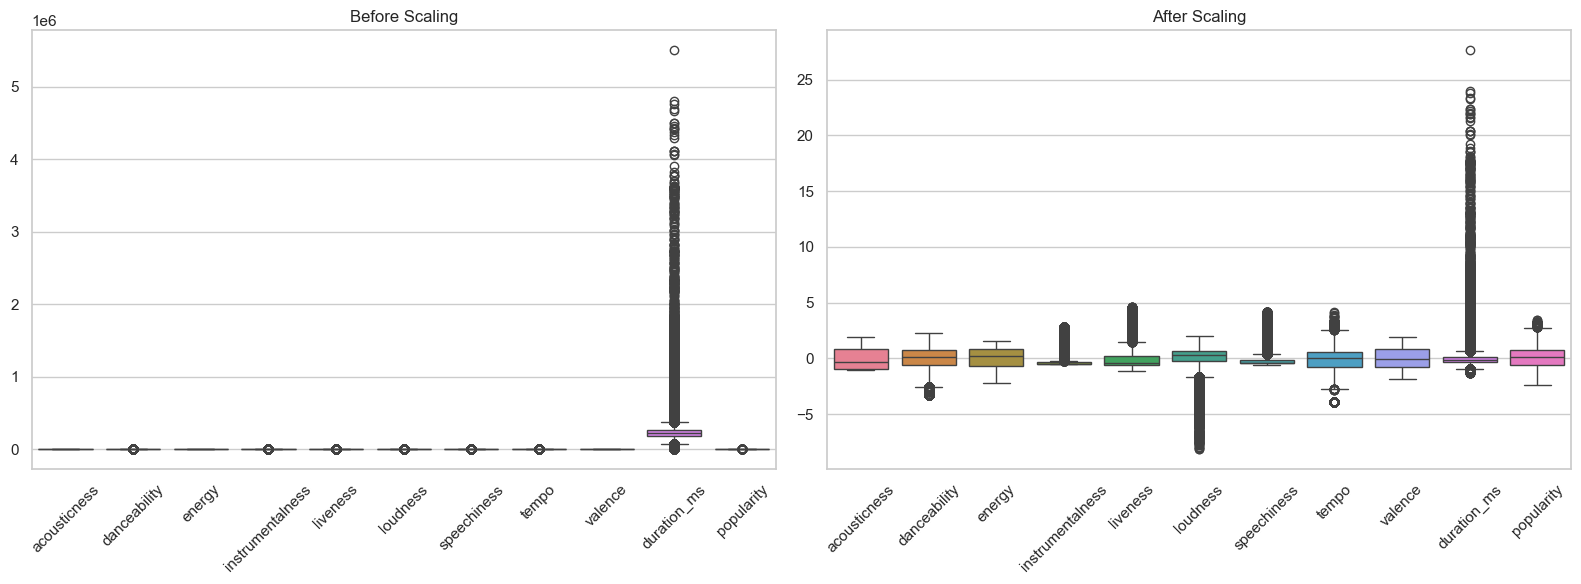

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

sns.boxplot(
    data=feature_df,
    ax=axes[0]
)

axes[0].set_title("Before Scaling")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=scaled_df,
    ax=axes[1]
)

axes[1].set_title("After Scaling")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.show()

Before scaling, several features operated on very different numerical ranges, especially duration and tempo. 

After standardization, all features are transformed to a comparable scale centered around zero. This prevents large-scale variables from dominating similarity calculations in recommendation models.

## 6. Correlation Matrix of Scaled Features

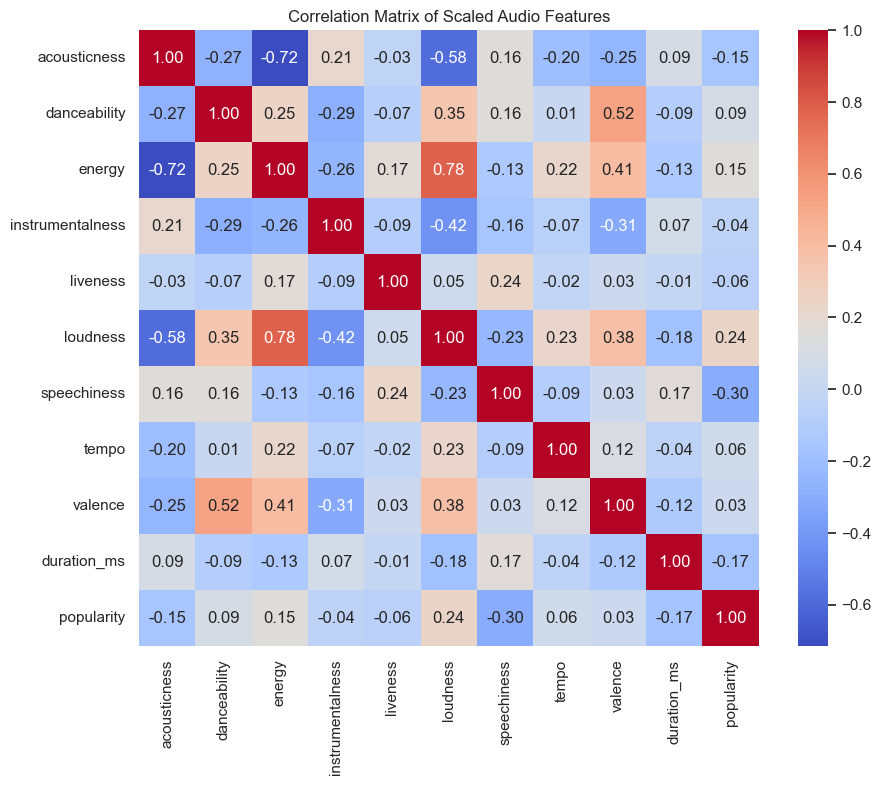

In [15]:
plt.figure(figsize=(10, 8))

corr_matrix = scaled_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Scaled Audio Features")

plt.show()

## 7. Duration Outlier Investigation

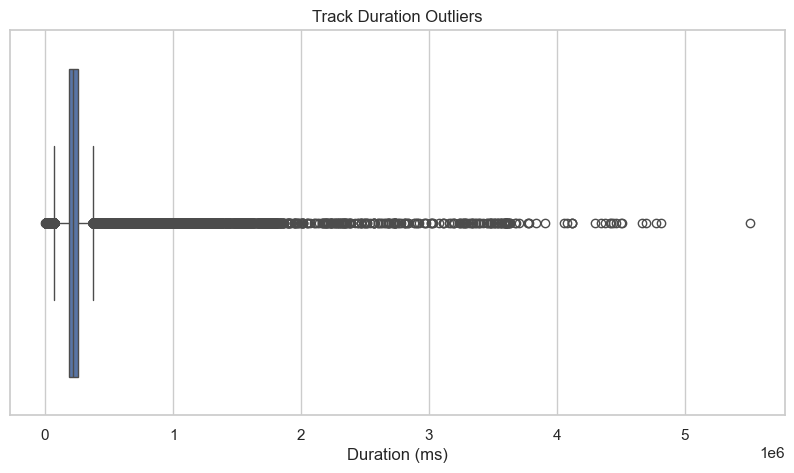

In [16]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=tracks["duration_ms"]
)

plt.title("Track Duration Outliers")

plt.xlabel("Duration (ms)")

plt.show()

In [ ]:
tracks.sort_values(
    by="duration_ms",
    ascending=False
)[
    ["name", "duration_ms", "popularity"]
].head(10)

## 8. Distribution of Standardized Features

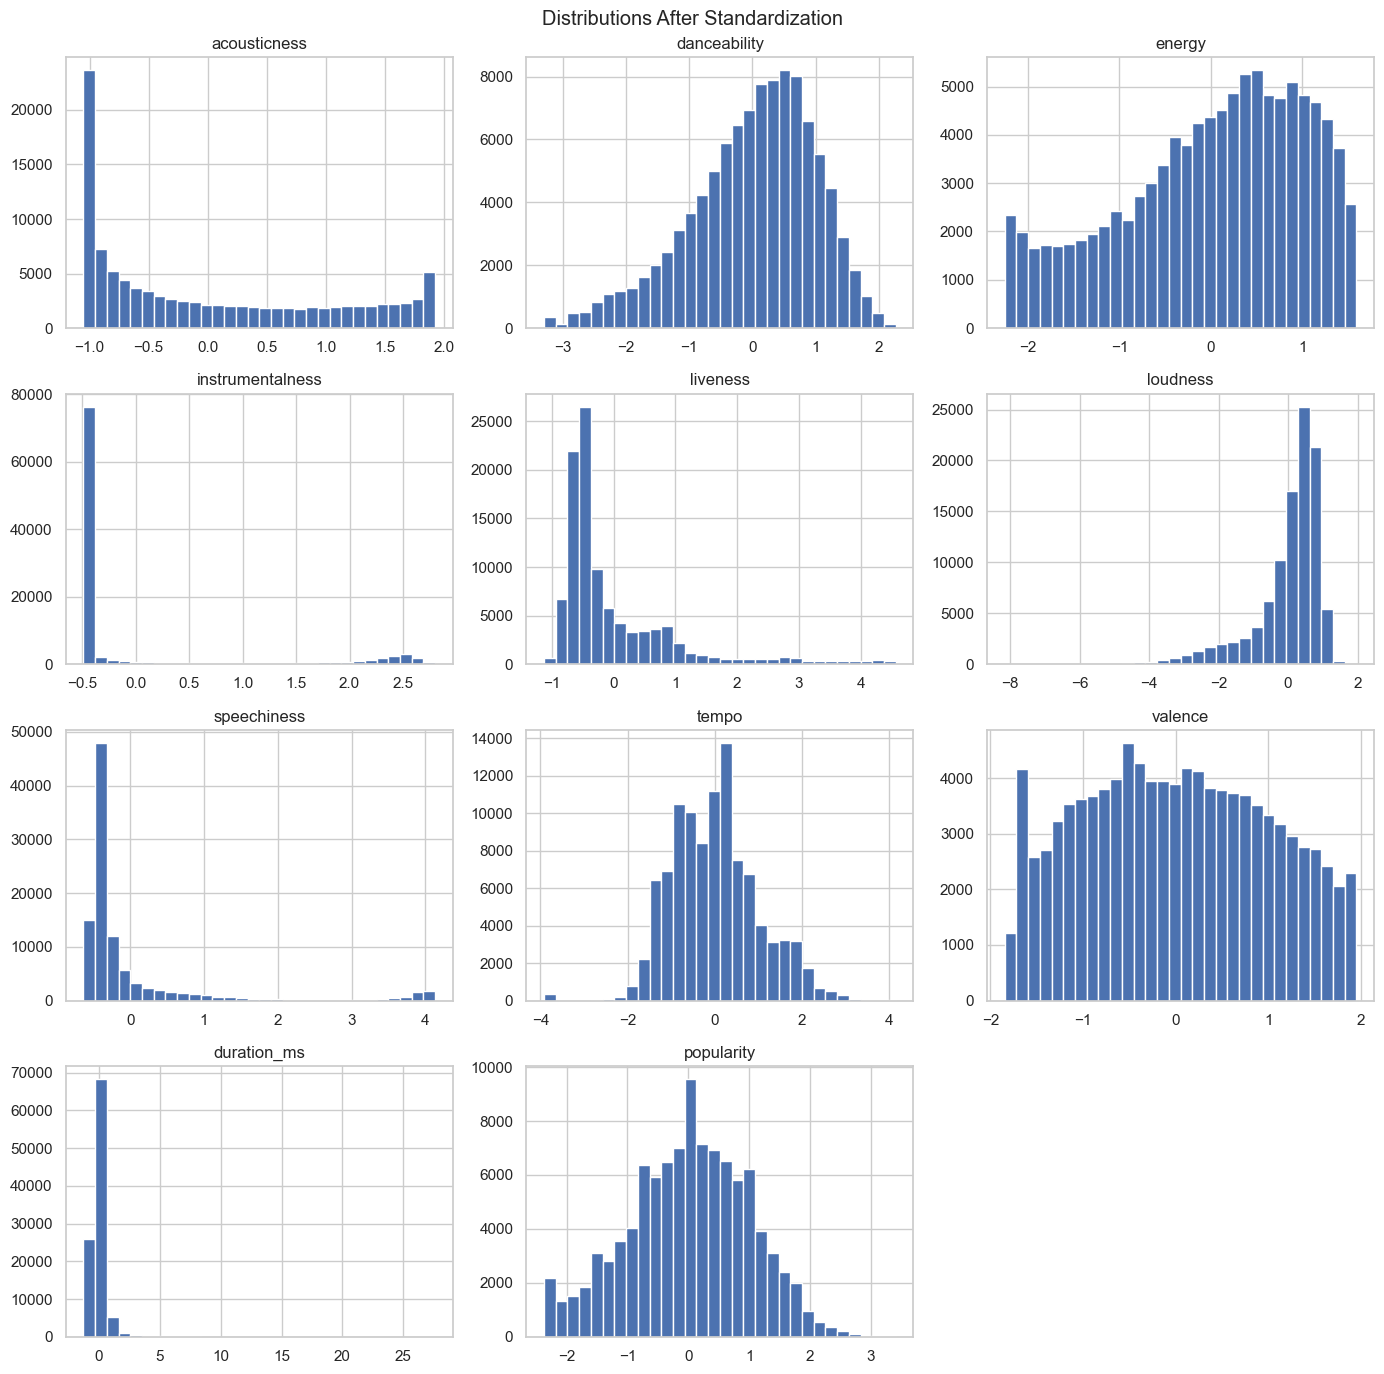

In [21]:
scaled_df.hist(
    figsize=(14, 14),
    bins=30,
    layout=(4, 3)
)

plt.suptitle("Distributions After Standardization")

plt.tight_layout()

plt.show()

## 9. Final Feature Matrix

In [18]:
final_feature_df = scaled_df.copy()

final_feature_df["track_name"] = tracks["name"]
final_feature_df["track_id"] = tracks["id"]

In [19]:
final_feature_df.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity,track_name,track_id
0,-0.173579,0.630108,0.075031,-0.489350,-0.265923,0.325196,-0.504821,-0.110526,0.531880,-0.058745,-0.701717,Blood,5qljLQuKnNJf4F4vfxQB0V
1,1.525671,0.748269,-1.070377,-0.489359,0.315638,-0.141532,3.900983,-0.108640,0.405777,2.154023,-0.523047,The Ugly Duckling,3VAX2MJdmdqARLSU5hPMpm
2,1.188210,-0.675291,1.324219,-0.489359,4.221220,-0.668274,4.009186,-1.283537,-1.520172,1.292181,-0.523047,Jimmy Launches His Own Range Of Greetings Cards,1L3YAhsEMrGVvCgDXj2TYn
3,1.227033,0.748269,-1.769922,-0.489359,-0.482583,-1.740957,3.979676,-0.183184,0.191782,0.366578,-1.535513,The Crime At Pickets Mill,6aCe9zzoZmCojX7bbgKKtf
4,1.247938,-0.709051,1.366499,-0.489359,4.101486,-0.691505,4.004267,-1.227456,-1.498773,1.638976,-0.463490,Setup + Punchline = Joke,1Vo802A38tPFHmje1h91um


In [20]:
final_feature_df.shape

(101939, 13)

## 10. Feature Engineering Notes for Recommendation System

The feature engineering process transformed the raw Spotify dataset into a standardized numerical representation suitable for recommendation models.

Main preprocessing steps included:
- selecting meaningful audio-related variables
- excluding metadata and identifiers
- standardizing numerical ranges
- identifying extreme outliers
- preparing the final feature matrix

The resulting dataset can now be used for similarity calculations, dimensionality reduction, and recommendation algorithms.

In [22]:
con.close()